# Module Tutorial: `modeltables`

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import tables as tb

import smfbursts as smf
import H2MMbursts as bhm


raw_hp3 = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data_hp3 = smf.photonHDF5.regularize_dets(raw_hp3)
data_hp3.irf_thresh[smf.PhSel('0ex0em')] = 2350

raw_yop = smf.loadraw.load_dir('data/Apo_50us ALEX_1hr/', finalizer='raw')
data_yop = smf.photonHDF5.regularize_dets(raw_yop)

# load saved optimized params
import os
statepathfile = 'data/statepathparams.hdf5'
if os.path.exists(statepathfile):
    with tb.open_file('data/statepathparams.hdf5', 'r') as f:
        statepaths_hp3 = [smf.Param.decode_group(g) for g in
                          f.list_nodes(f.root.HP3_TE300_SPC630.statepath_params)]
        statepaths_yop = [smf.Param.decode_group(g) for g in
                           f.list_nodes(f.root.Yopo_Apo.statepath_params)]
    
    brsts_hp3 = statepaths_hp3[0].base_param
    brsts_yop = statepaths_yop[0].base_param
else:
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))

    # optimize streams data
    dbs_hp3 = smf.fretfactory.make_bg(data_hp3, period=60.0, tail_min=5e-4,
                                     auto_threshold=True,
                                     func=smf.bg.exp_mlefit, F_bg=1.7)
    smf.fretfactory.make_burst_search(bg=dbs_hp3['bg'], m=10, F=6.0,
                                      update=dbs_hp3)
    gate_Allhp3 = smf.make_geq_gate(dbs_hp3['NphDex_raw'], 50)
    gate_Allhp3 = gate_Allhp3 & smf.make_geq_gate(dbs_hp3['NphAA_raw'], 25)
    smf.fretfactory.apply_gate(dbs_hp3, gate_Allhp3)
    brsts_hp3 = dbs_hp3['bursts']
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
    statepaths_hp3 = bhm.StatePath.optimize_models(
        data_hp3, brsts_hp3, streams=streams, max_states=8,
        min_states=1, to_state=4, conv_crit='BICph')
    
    # optimize multiparameter usAlex data
    dbs_yop = smf.fretfactory.make_bg(data_yop, period=60.0, F_bg=1.7,
                                      func=smf.bg.exp_mlefit,
                                      tail_min=5e-4, auto_threshold=True)
    smf.fretfactory.make_burst_search(bg=dbs_yop['bg'], m=10, F=6.0, 
                                      streams=smf.PhSel('0ex_1ex1em'),
                                      update=dbs_yop, nbva=5)
    gate_Allyop = smf.make_geq_gate(dbs_yop['NphDex_raw'], 50)
    gate_Allyop = gate_Allyop & smf.make_geq_gate(dbs_yop['NphAA_raw'], 30)
    gate_FRETyop = gate_Allyop& smf.make_range_gate(dbs_yop['S_bg'], 0.25, 0.7)
    smf.fretfactory.apply_gate(dbs_yop, gate_FRETyop)
    shifts = ('base', 'base', 'neven:0')
    statepaths_yop = bhm.usAlexStatePath.optimize_models(
        data_yop, dbs_yop['bursts'], streams=streams, shifts=shifts, 
        conv_crit='BICph', thresh=0.005)

## The `StatePath ` class

In H2MMbursts, $\mathrm{H^{2}MM}$ models are most commonly wrapped in `bhm.StatePath` based `Param`s.
`bhm.StatePath` is technically a subclass of the abstract class `bhm.StatePathBase`, and represents the "default"
configuration of a table representing a $\mathrm{H^{2}MM}$ model, 
as well as the results of the *Viterbi* algorithm from the data and the model.

### `StatePath` parameters

The paramters of `bhm.StatePath` are
1. *model*: $\mathrm{H^{2}MM}$ model
2. *streams*: tuple of `smf.PhSel` which define which photon selections coorespond to which index in processing.

`bhm.StatePath` has 1 parent: *bursts*, definining the photon ranges over which to evaluate the *Viterbi* path.
This `smf.Param` is the *base_param* of `bhm.StatePath` based `smf.Param`

Usually, since $\mathrm{H^{2}MM}$ models are the result of optimizations,
we use the `bhm.StatePath.optimize` or `bhm.StatePath.optimize_models` class methods to
find the optimial model/models for the given number/numbers of states respectively.

For `bhm.StatePath.optimize`, the arguments are:
1. *origin* is the `smf.PhotonData` object of your data set,
2. *bursts* is the `smf.Param` (usually a `Bursts` base `smf.Param`, but any `smf.photondata.BasePhotonTable` will do),
   defining the time ranges to optimzie. This will be the *base_param* and parent of the output
3. *model* (optional, but highly encouraged) is the *initial* model (most imporant for defining the number of states).
   If not specified, the default will be 1 index for every stream, which is not always ideal, as some streams do not contain information
   e.g. in PIE measumrents the AexDem stream is essentially blank.
5. *streams* is the tuple of `smf.PhSel` defining the stream to index mapping for $\mathrm{H^{2}MM}$
6. *gate* (optional) a gate to be applied (if specified) to apply to *bursts* argument.


The class method returns optimized `smf.StatePath` based `smf.Param` will be returned.

In [2]:
out = bhm.StatePath.optimize(data_hp3, brsts_hp3, bhm.factory_h2mm_model(2,3), 
                             streams=(smf.PhSel('0ex0em'), 
                                      smf.PhSel('0ex1em'), 
                                      smf.PhSel('1ex1em')))
out.params

The model converged after 91 iterations


(('model',
  nstate: 2, ndet: 3, nphot: 0, niter: 0, loglik: -inf converged state: 0x8000
  prior:
  0.3899215909414825, 0.6100784090585175
  trans:
  0.9999738722984937, 2.6127701506397584e-05
  1.9602676011173197e-05, 0.9999803973239888
  obs:
  0.1436383367939425, 0.21938737636570774, 0.6369742868403497
  0.5423570980863497, 0.08581762899942048, 0.3718252729142298),
 ('streams',
  (<class 'smfbursts.ph_sel.PhSel'>
   <class 'smfbursts.ph_sel.PhStream'>
   ex = (True):(0)
   em = (True):(0)
   pol = all
   split = all,
   <class 'smfbursts.ph_sel.PhSel'>
   <class 'smfbursts.ph_sel.PhStream'>
   ex = (True):(0)
   em = (True):(1)
   pol = all
   split = all,
   <class 'smfbursts.ph_sel.PhSel'>
   <class 'smfbursts.ph_sel.PhStream'>
   ex = (True):(1)
   em = (True):(1)
   pol = all
   split = all)))

For `bhm.StatePath.optimize_models`, while it is possible to specify initial models for each number of states,
it by default uses the `bhm.factory_h2mm_model` function to generate models for each state.
So only the bursts and streams are stricly necessary.

The `origin`, `bursts` and `streams` arguments define the input data to the H<sup>2</sup>MM algorithm.
The remaining arguments define optimization limits parameters.
These are

1. `conv_crit='pathBIC'` criterion to use to determine if optimizations have converged
2. `to_state=4` minimum number of states to optimize, regardless of convergence criterion
3. `min_states=1` which number of states to begin optimizing at
4. `max_states=8` maximum number of states to optimize, regardless of convergence criterion
5. additional kwargs are assumed to be inputs to
   [H2MM_C.h2mm_model.optimize()](https://h2mmpythonlib.readthedocs.io/en/latest/Documentation.html#H2MM_C.h2mm_model.optimize)
   Some useful parameters are:
    1. `max_iter` set the maximum number of iterations per optimization
    2. `converged_min` set the minimum difference in loglikelihood between rounds to consder model optimized
   
Below is a typical example optimization:

In [3]:
################################################################################
# Comment out the following lines to save time                                 #
# The results of this were saved in the HDF5 file loaded in the beginning of   #
# of the tutorial.                                                             #
################################################################################
_ = bhm.StatePath.optimize_models(
    data_hp3, brsts_hp3, 
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')),
    min_states=1, to_state=4, max_states=8, conv_crit='BICph')
###############################################################################

# Output
[(o.tp, o.params['model'].nstate) for o in statepaths_hp3]

The model converged after 4 iterations
The model converged after 91 iterations
The model converged after 222 iterations
The model converged after 215 iterations
Optimization reached maximum number of iterations


[(H2MMbursts.modeltables.StatePath, 1),
 (H2MMbursts.modeltables.StatePath, 2),
 (H2MMbursts.modeltables.StatePath, 3),
 (H2MMbursts.modeltables.StatePath, 4),
 (H2MMbursts.modeltables.StatePath, 5)]

### StatePath Columns

#### Transition Counting Columns

The StatePath has columns primarily based around results from the *Viterbi* algorithm.
Each photon in each burst is assigned most likely state by the *Viterbi* algorithm.
These values are always *per-burst*.

> **Note**
>
> See the `bhm.Dwells` table for columns that are per dwell (groups of consecutive photons with the same state)

##### *ntrans* column

The *ntrans* column simply counts the number of times consecutive photons 
are *not* in the same state (a  transition) within a given burst,
based on the model of the `StatePath` based `Param`.

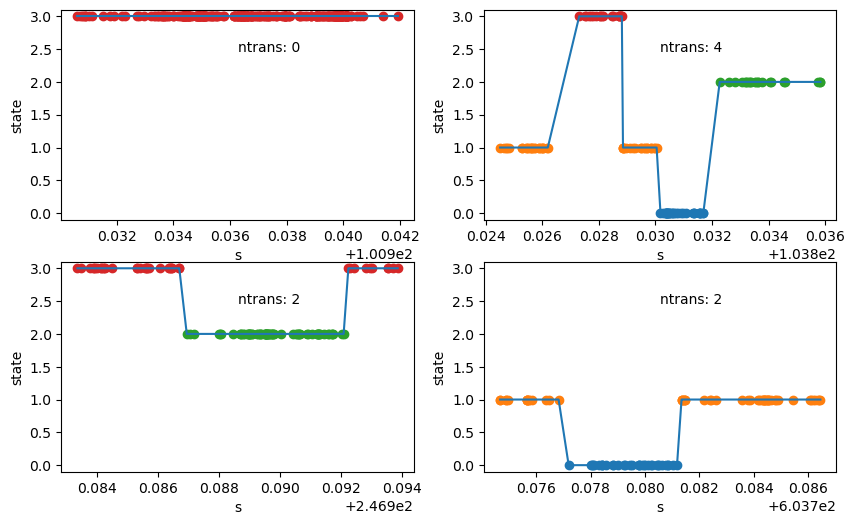

In [4]:
ns = 3 # set number of states (note this in index, so nstate = ns + 1)
ntrans = smf.Column(statepaths_hp3[ns], 'ntrans')

#
burst_nums = [[50, 52],[120, 300]]

# this allows you to specify 1d array for single row
burst_nums = np.atleast_2d(burst_nums)
# note that *burst_nums.shape makes 
# figsize =... sets figure size, [::-1] necessary as 
fig, axs = plt.subplots(*burst_nums.shape, 
                        figsize=[l*n for l, n in 
                                 zip((5, 3), burst_nums.shape[::-1])])



transitions = data_hp3.get_column(ntrans)

for ax, bn in zip(axs.ravel(), burst_nums.ravel()):
    out = bhm.plot.burst_state(data_hp3, statepaths_hp3[ns], bn, ax=ax)
    bhm.plot.burst_statepath(data_hp3, statepaths_hp3[ns], bn, ax=ax)
    ax.text(0.5, 0.8, f'ntrans: {transitions[bn]}', transform=ax.transAxes)
    ax.set_ylim([-0.1, ns + 0.1])

##### *transcount* column

The *transcount* column serves a similar, but more detailed.
Instead of treating all transitions as equal, 
each from->to transition is counted separately,
resulting in each row being a $n_{state} \times n_{state}$ array.
The diagonal is the number of times consecutive photons are in the same state.
Therefore often times the diagnoals have large values.

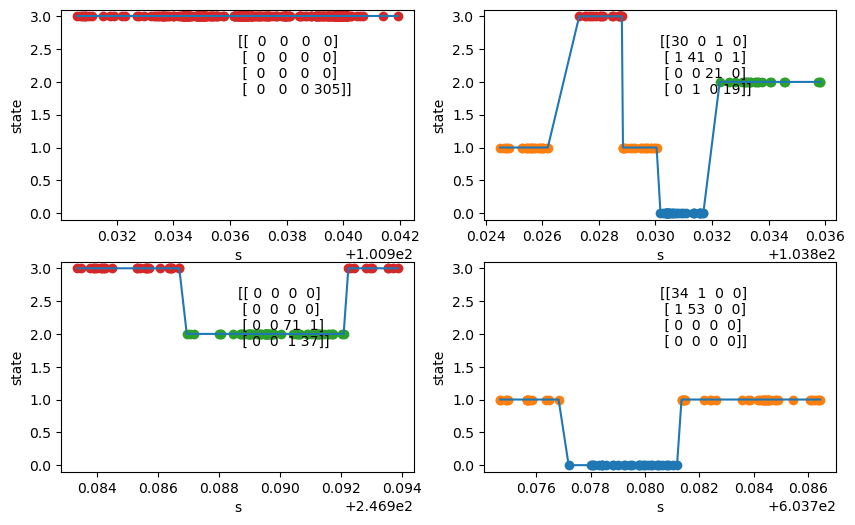

In [5]:
ns = 3 # set number of states (note this in index, so nstate = ns + 1)
tcounts = smf.Column(statepaths_hp3[ns], 'transcount')

#
burst_nums = [[50, 52],[120, 300]]

# this allows you to specify 1d array for single row
burst_nums = np.atleast_2d(burst_nums)
# note that *burst_nums.shape makes 
# figsize =... sets figure size, [::-1] necessary as 
fig, axs = plt.subplots(*burst_nums.shape, 
                        figsize=[l*n for l, n in 
                                 zip((5, 3), burst_nums.shape[::-1])])



transitions = data_hp3.get_column(tcounts)

for ax, bn in zip(axs.ravel(), burst_nums.ravel()):
    out = bhm.plot.burst_state(data_hp3, statepaths_hp3[ns], bn, ax=ax)
    bhm.plot.burst_statepath(data_hp3, statepaths_hp3[ns], bn, ax=ax)
    ax.text(0.5, 0.6, f'{transitions[bn]}', transform=ax.transAxes)
    ax.set_ylim([-0.1, ns + 0.1])

##### *bstates* column

The *bstates* identifies which states are present in the burst.
This is implemented as a bitmap.

That is, the value is an integer, and the bits that are 1 are the state present.

eg if state 0 and state 3 are present, but not 1 or 2 (for a 4 state model)
then 

`bstate = 0b1001 = 9`

or while if states 0, 1, and 2 are present, then

`bstate = 0b0111 = 7`

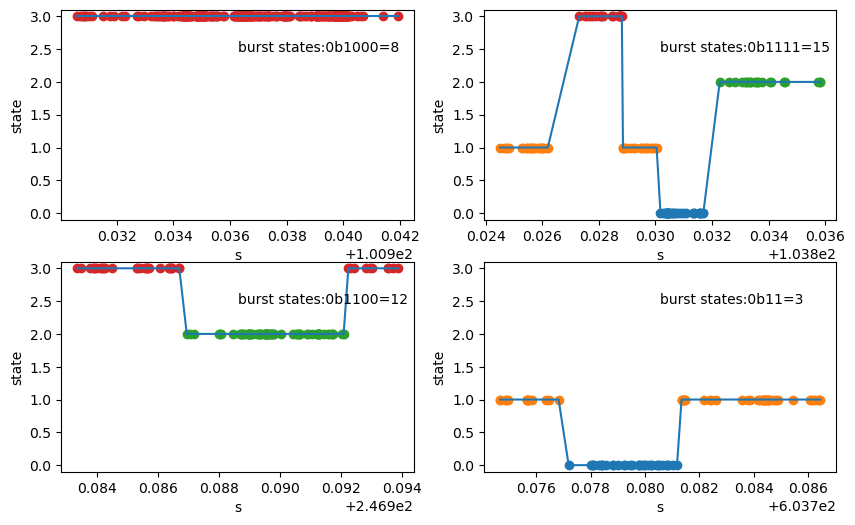

In [6]:
ns = 3 # set number of states (note this in index, so nstate = ns + 1)
bstates = smf.Column(statepaths_hp3[ns], 'bstates')

#
burst_nums = [[50, 52],[120, 300]]

# this allows you to specify 1d array for single row
burst_nums = np.atleast_2d(burst_nums)
# note that *burst_nums.shape makes 
# figsize =... sets figure size, [::-1] necessary as 
fig, axs = plt.subplots(*burst_nums.shape, 
                        figsize=[l*n for l, n in 
                                 zip((5, 3), burst_nums.shape[::-1])])



bcodes = data_hp3.get_column(bstates)

for ax, bn in zip(axs.ravel(), burst_nums.ravel()):
    out = bhm.plot.burst_state(data_hp3, statepaths_hp3[ns], bn, ax=ax)
    bhm.plot.burst_statepath(data_hp3, statepaths_hp3[ns], bn, ax=ax)
    ax.text(0.5, 0.8, f'burst states:{bin(bcodes[bn])}={bcodes[bn]}',
            transform=ax.transAxes)
    ax.set_ylim([-0.1, ns + 0.1])

#### Photon-by-Photon columns

##### *...path* columns

Similar to the *ph_...* columns of `smf.photondata.BasePhotonTable`s, `bhm.StatePath` based tables have a number of columns that
have rows of arrays which define the inputs and outputs of the base $H^{2}MM$ and *Viterbi* analysis.


The input columns are:

- *indexpath* theinput indexes of photons of $H^{2}MM$ processing
  (second input to
  `hm.viterbi_path`/`hm.h2mm_model.evaluate`/`hm.h2mm_model.optimize`)
- *timepath* the input times of photons
  (second input to
  `hm.viterbi_path`/`hm.h2mm_model.evaluate`/`hm.h2mm_model.optimize`)
- *detpath* (not an input for $H^{2}MM$) that detector indexes
  (not re-indexed) of each photon

And the output columns are:

- *statepath* (int) most likely state of each photon by *Viterbi* algorithm
- *scalepath* (float) the posterior likelihood by *Viterbi* of each photon
- *pathllpath* (float) the likelihood of photon state assignemnet by *Viterbi*
  given the *Viterbi* path
- *gammapath* (n-state float) a 2d array, giving \[nstate, photon\]
  giving the likelihood of a given photon in a given state, assuming
  all possible statepaths that have that photon in that state.


We can use these columns to recreate the `bhm.plot.burst_statpath` function.
As you can see, we take a particular row of both *timepath* and *statepath*
to get the times and state locations of each photon in that burst,
and out comes a plot of the *viterbi* sequence.

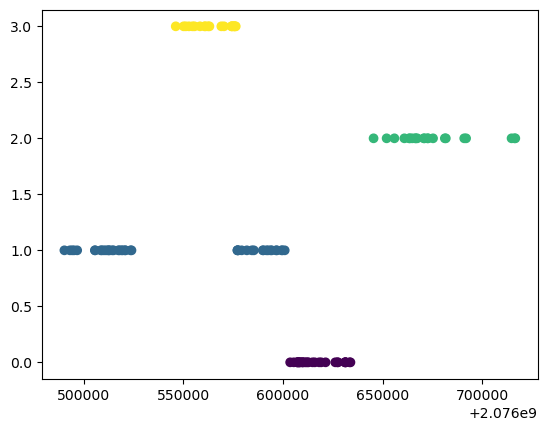

In [7]:
fig, ax = plt.subplots()

# choose favourite burst from previous plot of bursts
burst = burst_nums[0][1]

# make column objects of ...path type
timepath = smf.Column(statepaths_hp3[3], 'timepath')
statepath = smf.Column(statepaths_hp3[3], 'statepath')

# get relevant column and burst
times = data_hp3.get_column(timepath)[burst]
states = data_hp3.get_column(statepath)[burst]

ax.scatter(times, states, c=states)

##### *ph_...* columns

All of the *...path* columns have equivalent *ph_...* columns.
The *ph_...* columns function vary similar to the 
*ph_times*, *ph_dets*, and other *ph_...* columns of `smf.photondata.BasePhotonTable` tables like `smf.Bursts`.
They all have single `smf.PhSel` key, specifying which photon streams to filter by.

In the standard `bhm.StatePath` these columns will be equivalent to the *...path* column, 
**if** the key of the *ph_...* column is the `smf.PhSel` that is 
the union of all streams in the `StatePath` parameter *"streams"*.

For certain `bhm.StatePath`-like tables however, this is not necessaryily the case.
In particular, `bhm.usAlexStatePath` implements the shift function, which reorders
the photon so that differe exciation periods overlap.

In this case, the *...path* columns, the photons are ordered as in the $H^{2}MM$ analysis.
For *ph_...* columns, however, the photons are "put back" into the order of the original data.

> **Note**
>
> For those writing their own versions of `StatePath`:
> 
> If photons are reordered, the class should implement the following method:
> ```python
> def phsel_select(self, phsel:PhSel, col:str, fill:Any, dtype:np.dtype)->np.ndarray[np.object_]:
>     # code that maps H2MM order to "real" order of col, fills with fill
>     # should return array with dtype type
>     return <properly reordered array>
> ```


The full list of the `ph_...` columns is:

And the input-like columns are:

- *ph_index* - Index of photon used in $H^{2}MM$ analysis. Fill value is -1.
- *ph_h2mmtime* - time given to $H^{2}MM$
  (`usAlexStatePath` is only example in standard library where this is different from *ph_time*, )
  *h2mm* added to column name to prevent confusion with *ph_time*.
  Fill value is -1

The output-like columns:

- *ph_state*- *Viterbi* based most-likely state. Fill value is -1.
- *ph_scale*- posterior probablility computed by *viterbi* of given photon
  in most-likely state. Fill value is np.nan.
- *ph_pathll*- loglikilihood of givien photon in most-likely state. Fill value is nan.
- *ph_gamma*- probability of given photon in given state, over all paths that
  are in that state. Fill value is nan.
        

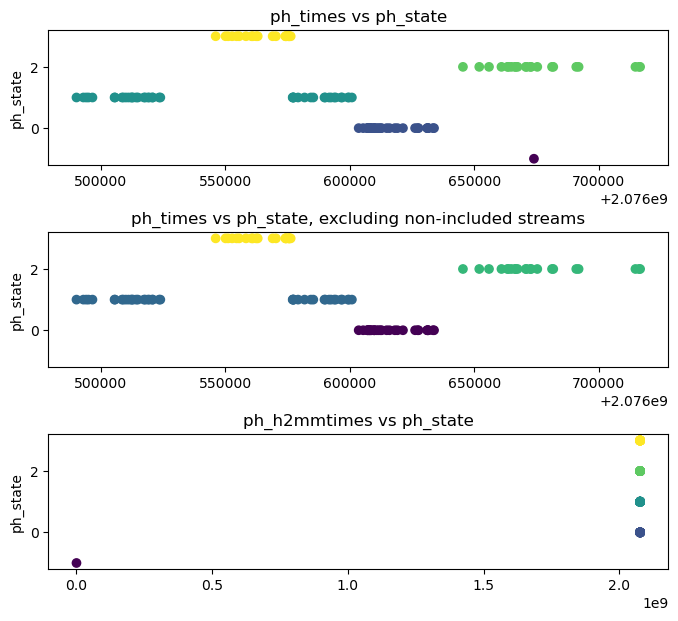

In [8]:
fig, ax = plt.subplots(3,1, figsize=(8,7), sharey=True, gridspec_kw={'hspace':0.5})

# choose favourite burst from previous plot of bursts
burst = burst_nums[0][1]

# make column objects of ...path type
rawtime = smf.Column(statepaths_hp3[3].parents['bursts'], 
                     'ph_times', smf.PhSel('all'))
phtime = smf.Column(statepaths_hp3[3], 'ph_h2mmtime', smf.PhSel('all'))
phstate = smf.Column(statepaths_hp3[3], 'ph_state', smf.PhSel('all'))

# get relevant column and burst
rtimes = data_hp3.get_column(rawtime)[burst]
ptimes = data_hp3.get_column(phtime)[burst]
states = data_hp3.get_column(phstate)[burst]

ax[0].scatter(rtimes, states, c=states)
ax[0].set_title('ph_times vs ph_state')
ax[1].scatter(rtimes[states!=-1], states[states!=-1], c=states[states!=-1])
ax[1].set_title("ph_times vs ph_state, excluding non-included streams")
ax[2].scatter(ptimes, states, c=states)
ax[2].set_title('ph_h2mmtimes vs ph_state')
for a in ax:
    a.set_ylabel("ph_state")

A final statepath-like column is *eff_state*, 
which takes a single `smf.PhSel` object as a key.
The purpose of this column is to allow state assignments 
for columns outside the streams used in $H^{2}MM$ analysis.
Here, photons not in the streams used by $H^{2}MM$ 
are assigned a state based on *Viterbi* state of the nearest photon 
that is used in $H^{2}MM$ processing.

Text(0.5, 1.0, 'ph_times vs eff_state')

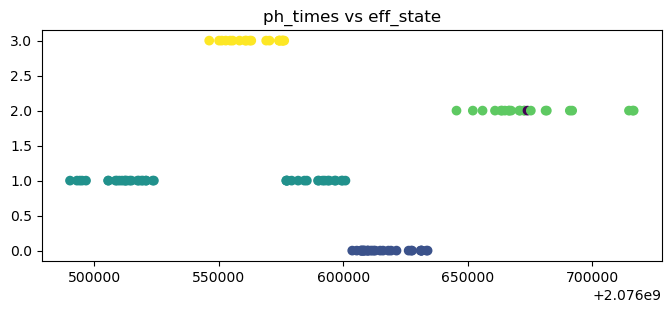

In [9]:
fig, ax = plt.subplots(1,1, figsize=(8,3), sharey=True)

# choose favourite burst from previous plot of bursts
burst = burst_nums[0][1]

# make column objects of ...path type
rawtime = smf.Column(statepaths_hp3[3].parents['bursts'], 
                     'ph_times', smf.PhSel('all'))
effstate = smf.Column(statepaths_hp3[3], 'eff_state', smf.PhSel('all'))

# get relevant column and burst
rtimes = data_hp3.get_column(rawtime)[burst]
estates = data_hp3.get_column(effstate)[burst]

ax.scatter(rtimes, estates, c=states)
ax.set_title("ph_times vs eff_state")

#### *nanohist_state* column

The *nanohist_state* column serves a special purpose.
It functions in a very similar way to the *nanohist* column of 
`smf.photondata.BasePhotonTable` based columns, but with some extra bells and whistles.

It has 4 keys: `phsel`, `thresh`, `discr` and `bool`
And each row is a nstate by tcspc-range array.

In [10]:
nhs0 = smf.Column(statepaths_hp3[3], 'nanohist_state', (smf.PhSel('0ex0em'), -2.0, 'ph_pathll'))
nhs1 = smf.Column(statepaths_hp3[3], 'nanohist_state', (smf.PhSel('0ex0em'), 0.5))

In [11]:
nshist0 = data_hp3.get_column(nhs0)
nshist1 = data_hp3.get_column(nhs1)

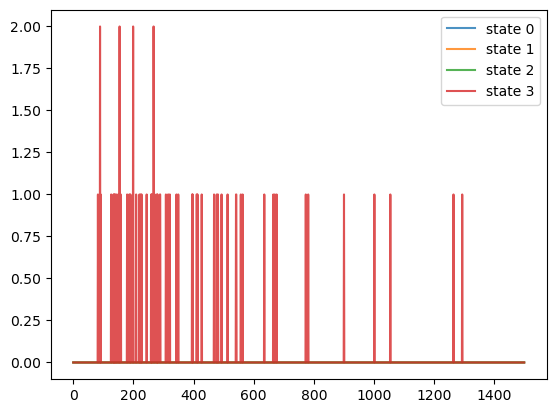

In [12]:
bnum = 51 # select which burst 
plt.plot(nshist0[bnum].T, label=[f'state {i}' for i in range(4)], 
         alpha=0.8)
plt.legend();

We can also use this to see the overall histograms by summing all bursts:

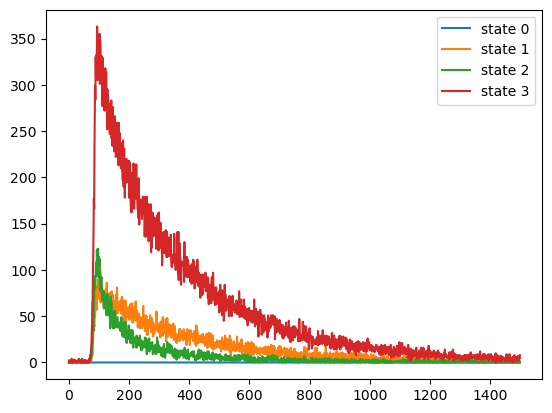

In [13]:
plt.plot(nshist0.sum(axis=0).T, label=[f'state {i}' for i in range(4)])
plt.legend()

#### Statistical discriminator columns

Just as the whole data set has a given loglikelihood, both for all statepaths, and for the *Viterbi* path,
so does each burst.

Thse can be accessed with the columns:
- *ll* loglikelihood of all statepaths (evaluated by $\mathrm{H^{2}MM}$)
- *pathll*

(<matplotlib.collections.PathCollection at 0x7f388995e930>,
 Text(0.5, 0, '$_{raw}n_{532ex}\\:+\\:_{raw}n_{642ex}^{698em}\\: (cnts)$'),
 Text(0, 0.5, 'll'))

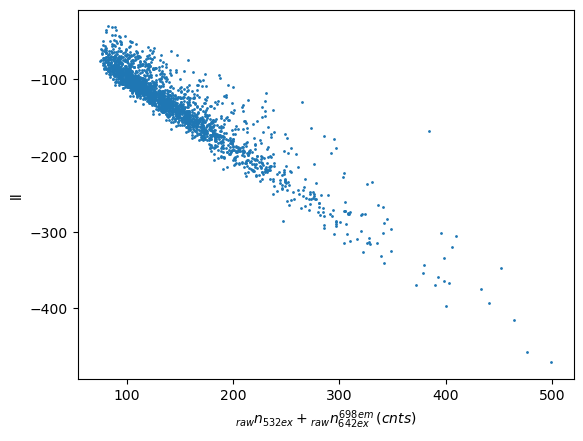

In [14]:
nph = smf.Column(statepaths_hp3[3].base_param, 
                 'nph_raw', smf.PhSel('0ex_1ex1em'))
llsp = smf.Column(statepaths_hp3[3], 'll')

smf.plot.scatter(data_hp3, nph, llsp, s=1.0)

(<matplotlib.collections.PathCollection at 0x7f3889534c50>,
 Text(0.5, 0, '$_{raw}n_{532ex}\\:+\\:_{raw}n_{642ex}^{698em}\\: (cnts)$'),
 Text(0, 0.5, 'llph'))

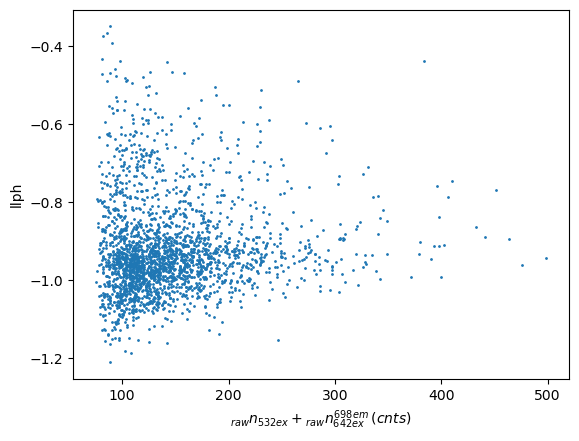

In [15]:
llphsp = smf.Column(statepaths_hp3[3], 'llph')

smf.plot.scatter(data_hp3, nph, llphsp, s=1.0)

### Data-wide parameters

Statistical discriminators also apply across the entire data set.
These are not always included in the base $\mathrm{H^{2}MM}$ model, 
and must be calculated against a given data set.

These are implemented as table methods of the given parameters.
As an example, the Bayes Information Criterion (BIC) can be accessed like so:

`param.BIC(data)`

Or 

`bhm.StatePath.BIC(statepath, data)`

In [16]:
statepaths_hp3[3].BIC(data_hp3)

np.float64(643353.5255885721)

These statistical discriminator methods have 2 keyword parameters, `as_array` and `from_flag`.
So the full signature is:

```python
bhm.Bursts.BIC(statpath, origin, as_array=False, from_flag=True)
```

`as_array` is only used with `origin` is a `smf.PhotonDataList` 
i.e. it is concatenating multiple data sets.
If `as_array` is `False`, then the statistical discriminator is assessed over all datasets collectively.
If `as_array` is `True`, then the return value will be an array of that statistical discriminator for each data set.
Keep in mind that the statistical discriminators have a pentalty based on the natural logarithm of the number of photons.
Therefore the sum of the array will *not* be the same as the non-array discriminator, as the penalty for photons will be different.

`from_flag` indicates whether or not to check the flags dictionary of the param to see 
if the statistical discriminator has already been computed and stored in the flags dictionary for the given data set.
If `from_flag` is `True`, then, if the value was already calculated and stored, the function will simply access that value.
If `from_flag` is `False` it will force recalculation.

#### Statistical Discriminators

The following statistical discriminators are available:

- `BIC` Bayes Information Criterion, based on likelihood of all possible statepaths
- `BICph`Bayes Information Criterion per fphoton
- `BICp` modified Bayes Information Criterion, as in (Lerner 2018)[https://doi.org/10.1063/1.5004606]
- `ICL` Integrated Complete Likelihood, based on posterior probability of *Viterbi* path
- `ICLph` Integrated Complete Likelihood, per photon
- `pathBIC` BIC based on likelihood of *Viterbi* path
- `pathBICph` pathBIC per photon

#### transrate

There is also the `bhm.StatePath.transrate` tableproperty.
This has the same basic signature as the statistical discriminators (though without the `as_array` or `from_flags` keyword arguments).
And returns the clock-rate units transition probability matrix of the model, into a transition rate matrix in units of transitions per second.

In [17]:
statepaths_hp3[3].transrate(data_hp3)

array([[1.99993601e+07, 2.03049776e+02, 5.49253947e+01, 3.81936775e+02],
       [1.65034452e+02, 1.99993924e+07, 5.97752630e+01, 3.82749088e+02],
       [2.35704374e+01, 3.06170363e+01, 1.99996158e+07, 3.30001057e+02],
       [9.72168184e+01, 8.61925333e+01, 1.61480779e+02, 1.99996551e+07]])

#### Model parameters

There are also paramproperties that compute the expected values from the model of certain columns.

These are:

- `model_value`
- `model_values`

`model_value` takes a single column as the only required argument.

> **Note**
>
> The `origin` data can be specified as well, as a keyword argument.
> Depending on the column, it may be necessary to specify the origin, as extra metadate may be required.
>
> `model_value` and `model_values` internally depend on a class-attribute implemented dictionary
> that maps the column to a function for computing that column value from the $\mathrm{H^{2}MM}$ model
> to a column value. If that requires extra metadata from the data object, origin must be supplied

In [18]:
E_raw = smf.Column(brsts_hp3, 'E_raw')
S_raw = smf.Column(brsts_hp3, 'S_raw')
statepaths_hp3[3].model_value(E_raw), statepaths_hp3[3].model_value(S_raw)

(array([0.47315095, 0.08224331, 0.66106896, 0.17048291]),
 array([0.14814003, 0.93626532, 0.45181672, 0.54576315]))

`model_values` can take any number of columns as arguments, and returns a tuple of arrays, 1 for each column.

In [19]:
statepaths_hp3[3].model_values(E_raw, S_raw)

(array([0.47315095, 0.08224331, 0.66106896, 0.17048291]),
 array([0.14814003, 0.93626532, 0.45181672, 0.54576315]))

## The `usAlexStatePath` subclass

If you are trying to use multi-parameter $\mathrm{H^{2}MM}$ with a $\mathrm{\mu sALEX}$ setup,
you will need to use the `bhm.usAlexStatePath` subclass of `bhm.StatePath`.
This implements the workaroudn for the alternation period presented in 
[Harris 2022](https://doi.org/10.1038/s41467-022-28632-x).

`bhm.usAlexStatepath` behaves in most ways just like `bhm.StatePath`.
The key difference is the addition of a new parameters: *"shift"*.


### Shift styles

In the *"shift"* parameter, we input a sequence of strings, the same length as streams.
Here we specify how each stream should be shifted in time.

If a stream is already in the "correct" excitation period, it should be "base".

If a stream is to be shifted, there are a number of options.
There are 3 choices to be made in specifying the shift parametes.
1. Should excitation periods remain "**c**ontiguous",
   or should photons be shifted to the "**n**earest" possible destination period
2. What shifting method should be used
   Options are:
   - "even" recomended, even distribution so acceptor excitation
     photons carry only information about the exciation period
   - "shift" apply linear shift, computationally least expensive,
     but causes chance of artefacts from "overlaping" time information
   - "rand0x\<hexcode\>" Use random number generate (hexcode serves as seed)
     to give photons random times within appropriate period
3. Which excitation period should photons be shifted into?

The basic formula is `<c/n><shiftmethod>:<destination period>`

Below is an example of a basic optimization with `bhm.usAlexStatePath`.
Excitation period 0 is set as the base, so the first 2 streams are 'base',
then the final stream, since it a stream from the excitation period 1,
it gets a string ending in ':0' to indicate it should be shifted into
excitation period 0, the preceeding values are set as above, in this example
'neven', to indicate nearest, even distribution of photons.

In [20]:
################################################################################
# Comment out the following lines to save time                                 #
# The results of this were saved in the HDF5 file loaded in the beginning of   #
# of the tutorial.                                                             #
################################################################################
_ = bhm.usAlexStatePath.optimize_models(
    data_yop, brsts_yop,
    streams=(smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')),
    shifts=('base', 'base', 'neven:0'),
    min_states=1, to_state=4, max_states=8, conv_crit='BICph')
################################################################################   

[(o.tp, o.params['model'].nstate) for o in statepaths_yop]

The model converged after 2 iterations
The model converged after 111 iterations
The model converged after 779 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


[(H2MMbursts.modeltables.usAlexStatePath, 1),
 (H2MMbursts.modeltables.usAlexStatePath, 2),
 (H2MMbursts.modeltables.usAlexStatePath, 3),
 (H2MMbursts.modeltables.usAlexStatePath, 4),
 (H2MMbursts.modeltables.usAlexStatePath, 5)]

Below we can see how each shift style differs slightly in the reordering of photons.

It should be noted that while the *...path* columns will return arrays in the order seen below,
the *ph_...* columns remap the arrays back to the original order of the photons.

(11946.5, 11947.0)

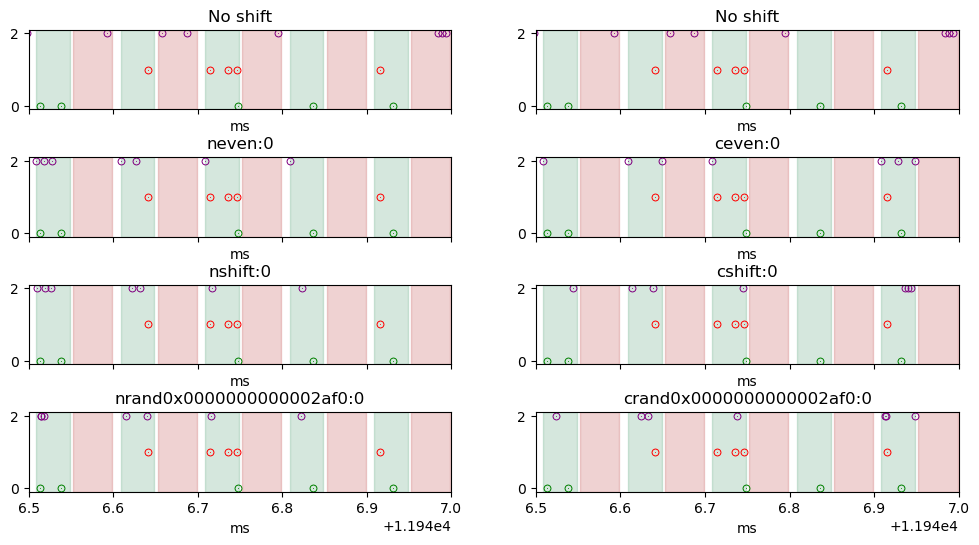

In [21]:
model = bhm.factory_h2mm_model(2,3)
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))

# make "dumy" statepaths (these are not optimized, not useful for analysis)
# the unshifted model
sp_nones = [smf.Param(bhm.StatePath, 
                      params={'model':model, 'streams':streams},
                      parents={'bursts':brsts_hp3})]*2
# example of even shift
evens = [('base', 'base', f'{cn}even:0') for cn in ['n', 'c']]
sp_evens = [smf.Param(bhm.usAlexStatePath, 
                      params={'model':model, 'streams':streams, 'shifts':even},
                      parents={'bursts':brsts_hp3}) for even in evens]
# example of shift shift
shifts = [('base', 'base', f'{cn}shift:0') for cn in ['n', 'c']]
sp_shifts = [smf.Param(bhm.usAlexStatePath, 
                       params={'model':model, 
                               'streams':streams, 'shifts':shift},
                       parents={'bursts':brsts_hp3}) for shift in shifts]
# example of rand shift
rands = [('base', 'base', f'{cn}rand0x2af0:0') for cn in ['n', 'c']]
sp_rands = [smf.Param(bhm.usAlexStatePath, 
                    params={'model':model, 'streams':streams, 'shifts':rnd},
                    parents={'bursts':brsts_hp3}) for rnd in rands]

sp_list = [sp_nones, sp_evens, sp_shifts, sp_rands]

fig, ax = plt.subplots(4, 2, figsize=(12,6), 
                       gridspec_kw={'hspace':0.6}, sharex=True)
b = 10

index_pos = {0:0.0, 1: 1.0, 2:2.0}
index_kwargs = {0:{'c':'g'}, 1:{'c':'r'}, 2:{'c':'purple'}}

# build kwargs to set colors of excitation ranges
ex_clrs = ['seagreen', 'firebrick'] # colors of each excitation range
span_kwargs = [{'color':c} for c in ex_clrs] # list of dicts for each color
alt_span_kwargs = {'alpha':0.2, 'span_kwargs':span_kwargs} # input dict

# loop to build grid of plots
for i, sps in enumerate(sp_list):
    for j, sp in enumerate(sps):
        if sp is None:
            ax[i,j].set_axis_off()
            continue
        bhm.plot.burst_index(data_yop.datas[0], sp, b, ax=ax[i,j], 
                             linewidths=5.0, s=0.5, zerostart=False, rescale=-3,
                             index_pos=index_pos, index_kwargs=index_kwargs,
                             alt_span=True, alt_span_kwargs=alt_span_kwargs)
        ttl = sp.params['shifts'][-1] if 'shifts' in sp.params else 'No shift'
        ax[i,j].set_title(ttl)
    
ax[0,0].set_xlim([11946.5, 11947.0])

### The `bhm.ntdivStatePath` class

This class implements the divisor base approach first demonstrated in 
[Harris 2022](https://doi.org/10.1016/j.bpr.2022.100071)

It is a subclass of `bhm.StatePath`, and adds the *divs* parameter.

This parameter defines where to place divisors per photon stream based on photon nanotime.
Photons are assigned indexes based both on their nanotime relative to the divisor, and their photon stream.

The *divs* parameter must be a tuple of arrays, the length of the tuple matching the number of streams in the *streams* parameter.
The number of elements in a given array is the number of divisors for the given stream.

Below we visualize this scheme by making a dummy param, and then plotting an example burst:

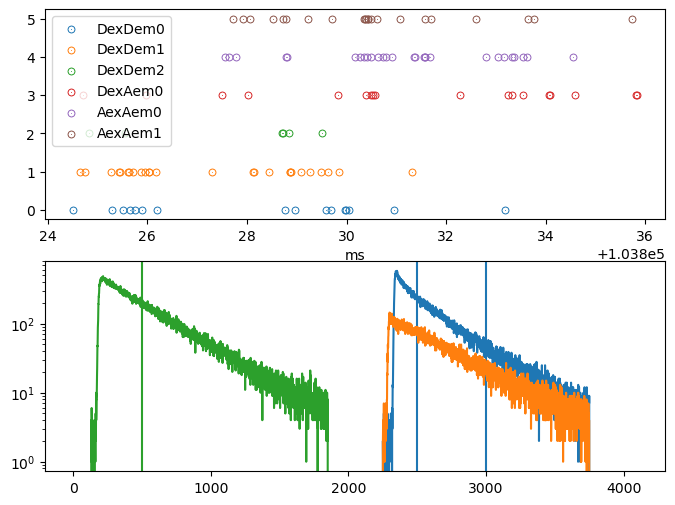

In [22]:
model = bhm.factory_h2mm_model(2,6)
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
divs = (np.array([2500, 3000]), np.array([]), np.array([500,]))
# dummy param to demonstrate divisors
sp_ntdiv = smf.Param(
    bhm.ntdivStatePath,
    params={'model':model, 'streams':streams, 'divs':divs}, 
    parents={'bursts':brsts_hp3}
)

fig, ax = plt.subplots(2, 1, figsize=(8,6))
bhm.plot.burst_index(data_hp3, sp_ntdiv, 52, ax=ax[0],
                     linewidths=5.0, s=0.5, zerostart=False, rescale=-3,
                     index_kwargs={0:{'label':'DexDem0'}, 
                                   1:{'label':'DexDem1'}, 
                                   2:{'label':'DexDem2'}, 
                                   3:{'label':'DexAem0'}, 
                                   4:{'label':'AexAem0'}, 
                                   5:{'label':'AexAem1'}, 
                                  })
ax[0].legend()

def get_nanohist(data:smf.photondata.PhotonDataS, param:smf.Param, ph_sel:smf.PhSel)->np.ndarray[np.int64]:
    col = smf.Column(param, 'nanohist', (ph_sel, True))
    func = data.get_column if isinstance(data, smf.PhotonData) else data.concatenate_column
    return func(col).sum(axis=0)

for stream, div in zip(streams, divs):
    c = ax[1].semilogy(get_nanohist(data_hp3, brsts_hp3, stream))
    for v in div:
        ax[1].axvline(v, c=c[0].get_color())

The `sbhm.ntdivStatePath.optimize` and `sbhm.ntdivStatePath.optimize_models`
class methods behave equivalently to `bhm.StatePath`, where the only addition is the
`divs` keyword argument.

Below is an example of an optimization using only the DexDem stream to demonstrate
a pseudo-single fluorophore type of $\mathrm{H^{2}MM}$ optimization:

In [23]:
sp_ntdivs = bhm.ntdivStatePath.optimize_models(
    data_hp3, brsts_hp3, 
    streams=streams[:1], divs=divs[:1]
)

The model converged after 1 iterations
The model converged after 304 iterations
Optimization reached maximum number of iterations
Optimization reached maximum number of iterations


#### Lifetime values from model with `bhm.ntdivStatePath` params

Because divisors allow computation of lifetime, the expected liftime
of states can be computed from `bhm.ntdivStatePath` based `smf.Param`

With these values it is necessary to supply the `smf.PhotonData` object,
as it contains critical information on the scale of nanotimes.

> **Note**
>
> Inference of the lifetime from the model of a given state is done by computing
> the ratio of the proability of the first divisor (from the obs array)
> entirely after the `irf_thresh`, and the remaining divisors.
>
> The formula is as follows:
> Given the divisors $\{d_{0}, d_{1}, ...\}$,
> take the first divisor $d_{min}$ greather than the irf threshold. and the next smallest divisor $d_{min+1}$
> And the emission proabilities in the indexes defined by
> $P_{min} = P(d_{min} \leq t \le d_{min+1})$ and the sum of
> all divisors in the stream $P_{rem} = P(t \geq d_{min+1})$.
>
> From this, the lifetime is calculated as $\tau = \frac{d_{min+1}-d_{min}}{\ln(P_{min}/P_{rem}+1)}$
> Note that formula is only valid if the longest time (tcspc range) is long enough for the maximum time to be able to be considered infinite.

In [24]:
nanomean_DD = smf.Column(brsts_hp3, 'nanomean', smf.PhSel('0ex0em'))

sp_ntdivs[3].model_value(nanomean_DD, data_hp3, strict=False)*1e9

array([3.09117393, 4.01334235, 3.47470381, 4.10705933])

## The `Dwells` class

The `bhm.Dwells` table takes any `bhm.StatePathBase` subclass as it's parent, 
and creates a new set `smf.photontables.BasePhotonTable` (new set of rows) defined as *dwells*
e.i. time ranges within bursts of consecutive photons of the same state.

As a `smf.photontables.BasePhotonTable`, `bhm.Dwells` has all of the columns that go along with such tables.
So photon counts, durations, ratios etc. all come free with it.

There are a few additional columns specific to `bhm.Dwells` the following are short descriptions:

- Time Columns
    - rstart: the start of the dwell, in clk_p units, giving the midpoint if the dwell is in the middle of a burst, and the istarttime if dwell is first dwell in burst
    - rstart: the end of the dwell, in clk_p units, giving the midpoint if the dwell is in the middle of a burst, and the istoptime if dwell is final dwell in burst
- State based columns
    - state: the state of the dwell
    - iburst: the number of the burst from which the dwell arose, allows maping back to bursts
    - dwell_pos: key provides several options, a number related to the position of the dwell within the burst
- Restricted Raw Columns, like the *_raw* counterparts, but restricted to using inforamtion that can be gained from the $\mathrm{H^{2}MM}$ indexes.
  **Note** these columns are primarily used with `bhm.Dwells` that have a `bhm.usAlexStatePath` based `smf.Param` as their parent.
  As these columns take into account the re-ordered nature of the photons. For other `bhm.StatePathBase` subclasses,
  these are equivalent to *..._raw* columns.
    - nph_h2mm: number of photons in dwell, based on $\mathrm{H^{2}MM}$ indexes
    - ratio_h2mm: number of photons in dwell, based on $\mathrm{H^{2}MM}$ indexes
    - anisotropy_h2mm: anisotropy dwell, based on $\mathrm{H^{2}MM}$ indexes

### Visualizing dwells

Below photon state path is shown, with the dwells overlayed.
Note that since the rstart/rstop column is being used, if the bursts are in the middle of the dwell,
then the start/stop are based on the midpoint between the current dwell and the previous/next dwell,
while for the beginning/ending dwell, it is on the first/last photon of that dwell.
This means rstart/rstop are a hybrid between the start/stop and istarttime/istoptime columns, 
depending on whether the bursts are in the middle or beginning/ending of a burst.

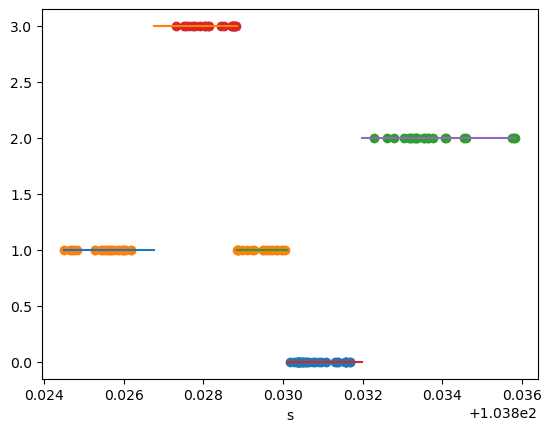

In [25]:
# make a dwells params from statepaths
dwell_hp3 = [smf.Param(bhm.Dwells, parents={'statepath':sp}) 
             for sp in statepaths_hp3]

# plot photons in burst 52
bhm.plot.burst_state(data_hp3, statepaths_hp3[3], 52)

iburst =  smf.Column(dwell_hp3[3], 'iburst')
dstate =  smf.Column(dwell_hp3[3], 'state')
rstart =  smf.Column(dwell_hp3[3], 'rstart')
rstop =  smf.Column(dwell_hp3[3], 'rstop')

# Loop over dwells, only plot dwells from burst #52, show start stop, and state
for ib, bs, rstart, rstop in zip(data_hp3.get_column(iburst),
                                 data_hp3.get_column(dstate),
                                 data_hp3.get_column(rstart),
                                 data_hp3.get_column(rstop)):
    if ib != 52: # if not burst 52, ignore
        continue
    plt.plot(data_hp3.clk_p*np.array([rstart, rstop]), [bs, bs])

#### The *state* column with a shift

The *state* column actually has a single key, which defaults to 0 if not specified.
This is the shift. It specifies how many dwells ahead (positive), or behind (negative) to look.

e.g. a state with shift of 1 means that the value for a given burst is the state of the *next* dwell.
and a shift of -1 is the state of the *previous* dwell.

Imporant to note however is that it only looks at dwells within the same burst.
So if the dwell is at the end of a burst, and the shift is 1, then the next dwell is in a different burst,
and so the value of that row in the column is -1.

Below is the same code that demonstrated the default 0 shift *state* column, but now with a shift incorporated.
You can rerun and/or duplicate the cell while chaning the value of the shift to see how it changes the results.

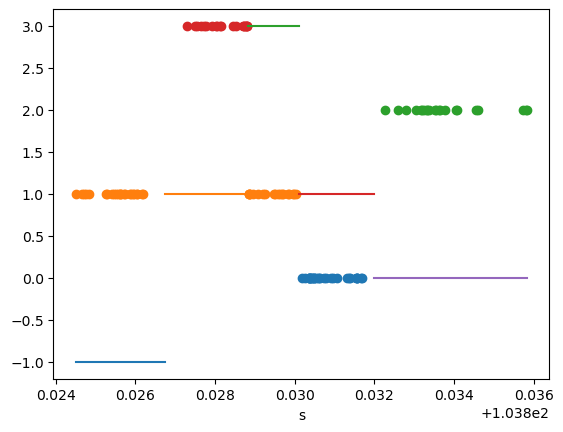

In [26]:
# make a dwells params from statepaths
dwell_hp3 = [smf.Param(bhm.Dwells, parents={'statepath':sp}) 
             for sp in statepaths_hp3]

# plot photons in burst 52
bhm.plot.burst_state(data_hp3, statepaths_hp3[3], 52)

iburst =  smf.Column(dwell_hp3[3], 'iburst')
dstate =  smf.Column(dwell_hp3[3], 'state', -1)
rstart =  smf.Column(dwell_hp3[3], 'rstart')
rstop =  smf.Column(dwell_hp3[3], 'rstop')

# Loop over dwells, only plot dwells from burst #52, show start stop, and state
for ib, bs, rstart, rstop in zip(data_hp3.get_column(iburst),
                                 data_hp3.get_column(dstate),
                                 data_hp3.get_column(rstart),
                                 data_hp3.get_column(rstop)):
    if ib != 52: # if not burst 52, ignore
        continue
    plt.plot(data_hp3.clk_p*np.array([rstart, rstop]), [bs, bs])

### The *dwell_pos* column

Options:
- 'since' number of dwells to begginning of burst
- 'until' number of dwells to end of burst
- 'min' min\[since, until\]
- 'max' max\[since, unitl\]
- 'nmin' signed min\[since, unil\] (if maximum is since, value is negative and shifted by -1)
- 'pos' "position" of dwell in burst. Beginning/ending/whole burst
  dwells have values of -1, -2, and -3 respectively, otherwise
  give result of min

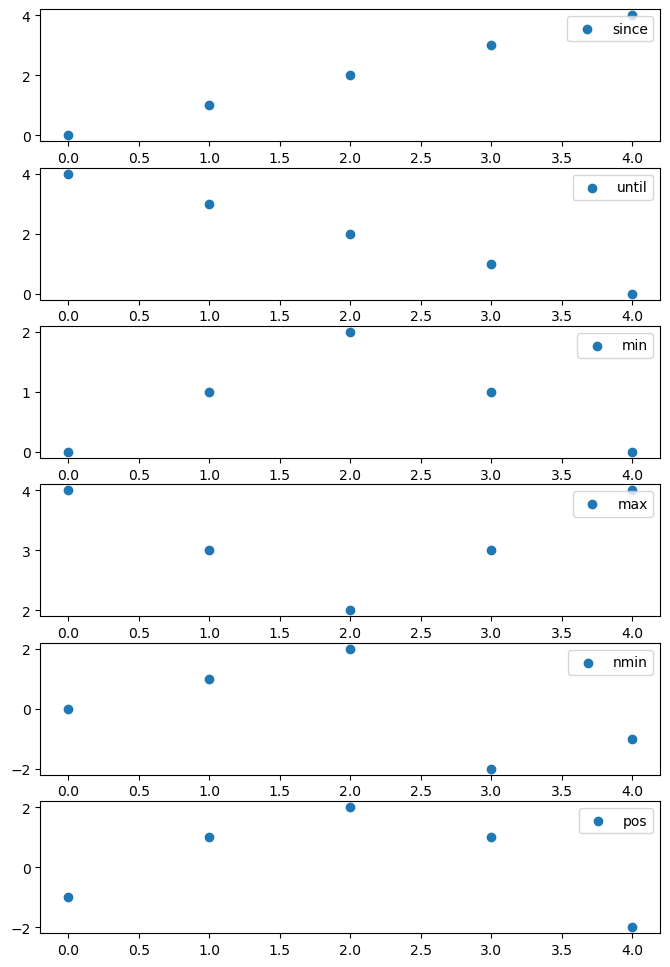

In [27]:
pcodes = ('since', 'until', 'min', 'max', 'nmin', 'pos')

fig, axs = plt.subplots(len(pcodes), figsize=(8, 2*len(pcodes)))

mask = data_hp3.get_column(iburst) == 52
for pcode, ax in zip(pcodes, axs):
    arr = data_hp3.get_column(smf.Column(dwell_hp3[3], 'dwell_pos', pcode))
    ax.scatter(np.arange(arr[mask].size), arr[mask], label=pcode)
    ax.legend()

## `StatePathFilter` class

Inspired by the suggestion of [Kache & Hendrix, 2025](https://doi.org/10.1186/s44330-025-00039-2),
the `bhm.bursttables.StatePathFilter` provides a way of creating
bursts filtered by $\mathrm{H^{2}MM}$ *Viterbi* states.

`bhm.modeltables.StatePathFilter` is a `smf.photondata.BasePhotonTable`,
so it defines a new set of rows.

It has 1 parameter: 
-"exclude", a set of which states (ints) to remove.
and 1 parent: 
- "statepath", the `bhm.StatePath` which defines the states.

Below is an example `bhm.modeltables.StatePathFilter` based `smf.Param`,
where the states 0 and 1 are removed. This was chosen because these are the
Acceptor only and Donor only states, which are most likely to be removed.

In [28]:
# make param for excluding bursts
nb_burst = smf.Param(bhm.modeltables.StatePathFilter,
                     params={'exclude':{0,1}}, # remove blinking states
                     parents={'statepath':statepaths_hp3[3]})

Below is some code that shows how the times are filtered.
Grey boxes represent times that are in the filtered results,
photons are plotted by *Viterbi* state.

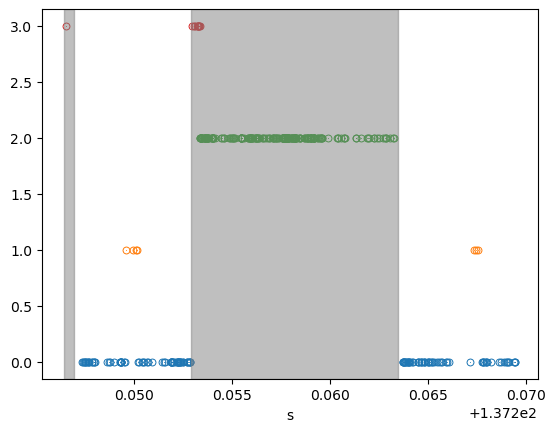

In [29]:
bnum = 70

# generate columns
nb_starts = smf.Column(nb_burst, 'start')
nb_stops = smf.Column(nb_burst, 'stop')
bs_starts = smf.Column(brsts_hp3, 'start')
bs_stops = smf.Column(brsts_hp3, 'stop')

# get column arrays
fstart = data_hp3.get_column(nb_starts)
fstop = data_hp3.get_column(nb_stops)
bstart = data_hp3.get_column(bs_starts)[bnum]
bstop = data_hp3.get_column(bs_stops)[bnum]

mask = (bstart <= fstart) & (fstop <= bstop)

bhm.plot.burst_state(data_hp3, statepaths_hp3[3], bnum, linewidths=5.0, s=0.5)

rngs = np.array([fstart[mask], fstop[mask]]).T
for strt, stp in rngs:
    plt.axvspan(strt*data_hp3.clk_p, stp*data_hp3.clk_p, 
                alpha=0.5, color='grey')

Thus concludes this tutorial.